In [1]:
import os
import sys
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("code"))
from protein_from_RNA import *

In [2]:
random_seed = 0

In [3]:
# ==== Transcription rate ====
alpha_mu = 2 # (Corresponds to ~7 mRNAs/hour, per Chronocell paper)
alpha_sd = 1

# === Splicing rate ===
beta_mu = 2 # np.log(splicing_rate) # (Corresponds to ~8.5 minute splicing rate, per Chronocell paper)
beta_sd = 0.5

# === mRNA degradation rate ===
gamma_mu = 0.5 # (Corresponds to ~2.8 hour half-life, per Chronocell paper)
gamma_sd = 0.5

# === Translation rate === 
median_transl_rate = 30 # (per Jovanovic paper)
transl_rate_mu = np.log(median_transl_rate) # Median of lognormal
transl_rate_sd = 1

# === Protein degradation rate === 
median_protein_deg_rate = .01 # (per Jovanovic paper)
protein_deg_rate_mu = np.log(median_protein_deg_rate) # Median of lognormal
protein_deg_rate_sd = 1.5

In [ ]:
# Simulate data

n = 1000 # No. cells per lineage
p = 200 # No. genes
topo = np.array([[0, 1, 2]])
tau = (0, 2, 6)

theta = get_RNA_params(topo, p, alpha_mu, alpha_sd, beta_mu, beta_sd, gamma_mu, gamma_sd, random_seed=random_seed)
phi = get_protein_params(p, transl_rate_mu, transl_rate_sd, protein_deg_rate_mu, protein_deg_rate_sd, random_seed=random_seed)
Y_observed, Y, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)
P_observed, P = simulate_protein_from_RNA(Y_observed, topo, true_t, true_l, phi, random_seed=random_seed)

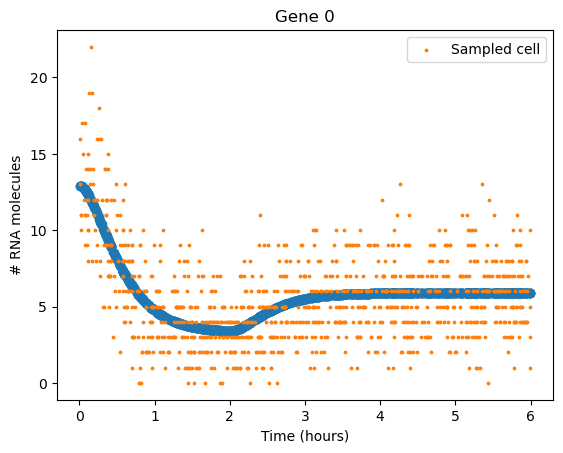

In [5]:
idx = 0

plt.scatter(true_t, Y[:, idx, 1]);
plt.scatter(true_t, Y_observed[:, idx, 1], s=3, label="Sampled cell");
plt.xlabel("Time (hours)");
plt.ylabel("# RNA molecules");
plt.title(f"Gene {idx}");
plt.legend();

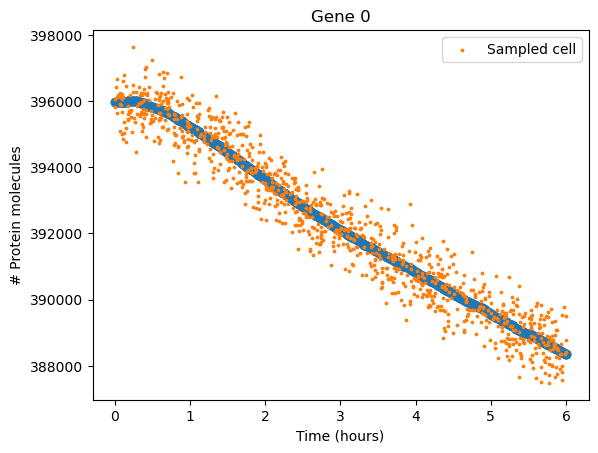

In [6]:
plt.scatter(true_t, P[:, idx]);
plt.scatter(true_t, P_observed[:, idx], s=3, label="Sampled cell");
plt.xlabel("Time (hours)");
plt.ylabel("# Protein molecules");
plt.title(f"Gene {idx}");
plt.legend();

# For a given gene:
## Calculate protein abundance from RNA levels using range of translation and protein degradation rates

In [9]:
# Now for each gene, sample a range of translation rates around true translation rate

n_resamples = 50
dispersion_factor = 2

In [10]:
P_transl_estimates_observed, P_transl_estimates, sampled_transl_rates = simulate_protein_transl_rate_sensitivity(Y_observed, topo, true_t, true_l, phi, dispersion_factor, n_resamples, random_seed=random_seed)
P_deg_estimates_observed, P_deg_estimates, sampled_deg_rates = simulate_protein_deg_rate_sensitivity(Y_observed, topo, true_t, true_l, phi, dispersion_factor, n_resamples, random_seed=random_seed)

UnboundLocalError: cannot access local variable 'deg_rates' where it is not associated with a value

In [16]:
sampled_transl_corrs = np.array([[np.corrcoef(P_transl_estimates_observed[r, :, idx], 
                                              P_observed[:, idx])[0, 1] for idx in range(p)] 
                                 for r in range(n_resamples)])

sampled_deg_corrs = np.array([[np.corrcoef(P_deg_estimates_observed[r, :, idx], 
                                           P_observed[:, idx])[0, 1] for idx in range(p)] 
                              for r in range(n_resamples)])

In [ ]:
gene_idx = 2

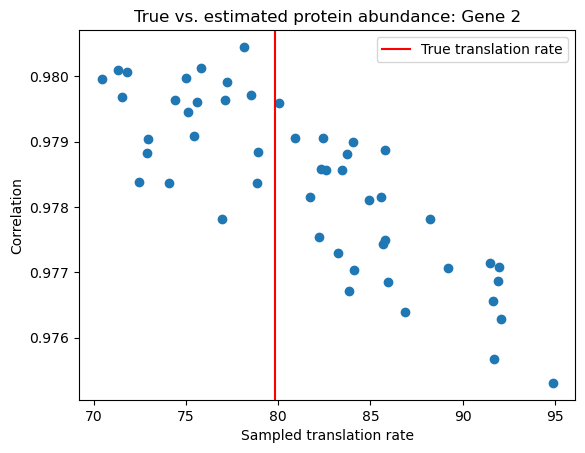

In [ ]:
plt.scatter(sampled_transl_rates[gene_idx, :], sampled_transl_corrs[:, gene_idx]);
plt.axvline(x=phi[gene_idx, 0], color='red', label="True translation rate")
plt.xlabel("Sampled translation rate");
plt.ylabel("Correlation");
plt.title(f"True vs. estimated protein abundance: Gene {gene_idx}");
plt.legend();

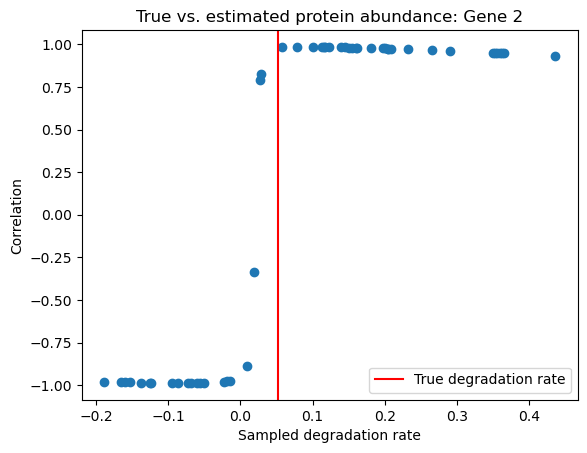

In [19]:
plt.scatter(sampled_deg_rates[idx, :], sampled_deg_corrs[:, idx]);
plt.axvline(x=phi[idx, -1], color='red', label="True degradation rate")
plt.xlabel("Sampled degradation rate");
plt.ylabel("Correlation");
plt.title(f"True vs. estimated protein abundance: Gene {idx}");
plt.legend();
# plt.xscale("sqrt");

In [ ]:
# For a given cell (Poisson sampled):
## Calculate its RNA history for each gene using: cell starting counts, and kinetic parameters (known) and recursive equation for expected # unspliced and spliced counts
